# Black Friday Sales Prediction

Predict customer purchase amounts from demographic, geographic, and product-level information using regression models.

**Dataset:** 550K+ Black Friday retail transactions  
**Target:** `Purchase`  
**Models:** Linear Regression, Decision Tree Regressor, Random Forest Regressor  
**Evaluation:** MAE, RMSE, R²


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")


In [4]:
# Load data
train = pd.read_csv(
    r"C:\Users\swaya\OneDrive\Desktop\Projects\black-friday-sales-prediction\dataset\train.csv"
)

test = pd.read_csv(
    r"C:\Users\swaya\OneDrive\Desktop\Projects\black-friday-sales-prediction\dataset\test.csv"
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (550068, 12)
Test shape: (233599, 11)


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [5]:
print(train.info())
print("\nMissing values:")
print(train.isnull().sum())

print("\nDuplicate rows:", train.duplicated().sum())
print("\nTarget summary:")
print(train["Purchase"].describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB
None

Missing 

## Exploratory Data Analysis

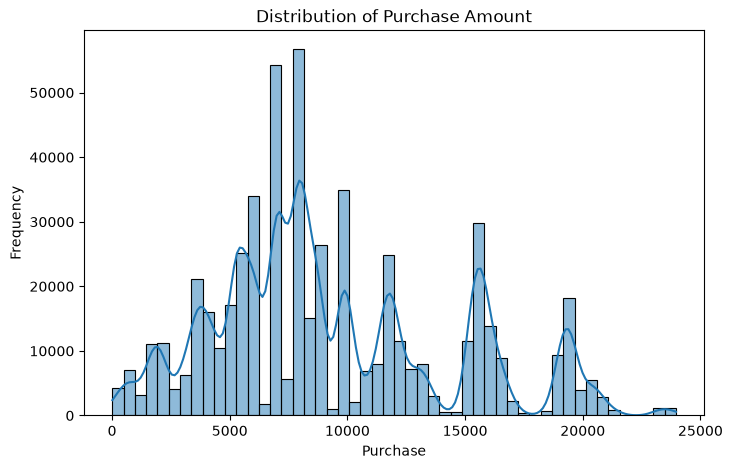

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(train["Purchase"], bins=50, kde=True)
plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase")
plt.ylabel("Frequency")
plt.show()


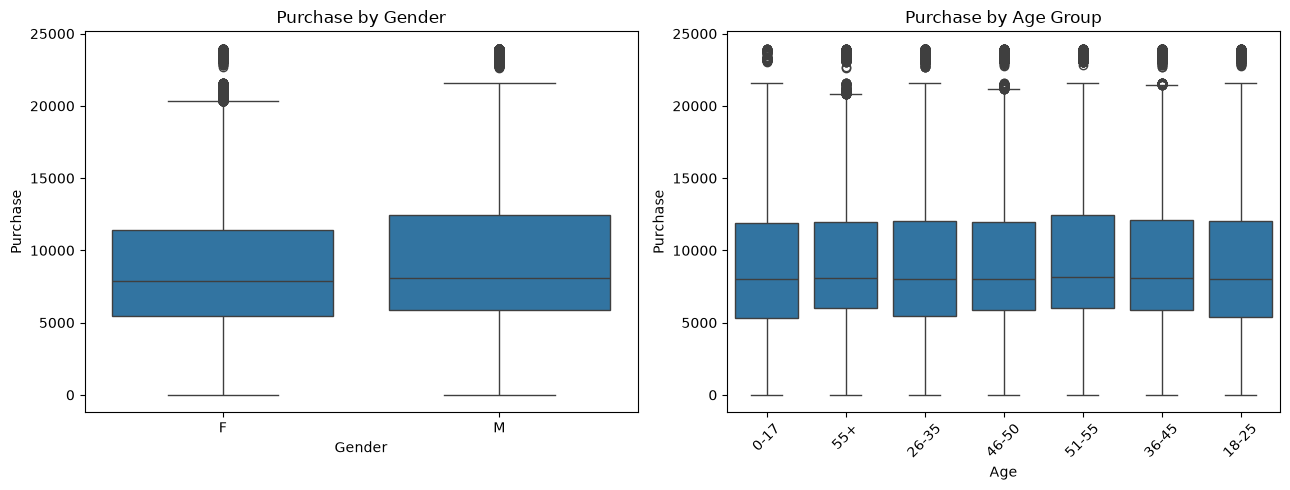

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.boxplot(data=train, x="Gender", y="Purchase", ax=axes[0])
axes[0].set_title("Purchase by Gender")

sns.boxplot(data=train, x="Age", y="Purchase", ax=axes[1])
axes[1].set_title("Purchase by Age Group")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


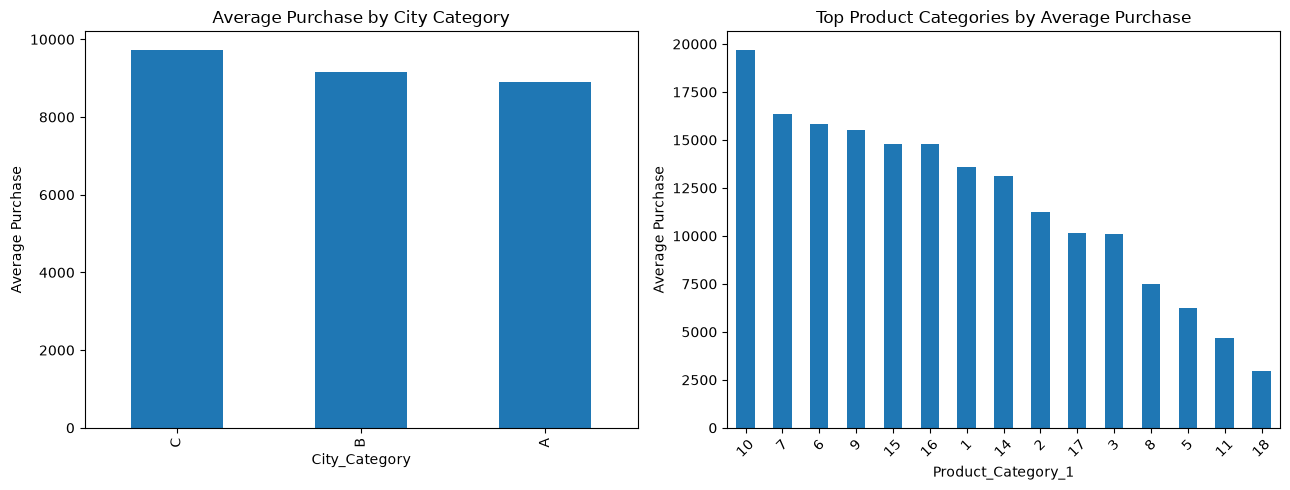

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

city_purchase = train.groupby("City_Category")["Purchase"].mean().sort_values(ascending=False)
city_purchase.plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Purchase by City Category")
axes[0].set_ylabel("Average Purchase")

cat_purchase = train.groupby("Product_Category_1")["Purchase"].mean().sort_values(ascending=False).head(15)
cat_purchase.plot(kind="bar", ax=axes[1])
axes[1].set_title("Top Product Categories by Average Purchase")
axes[1].set_ylabel("Average Purchase")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## Data Preparation

`Product_Category_2` and `Product_Category_3` contain missing values. Rather than calculating imputations before the split, preprocessing is fitted only on the training data through a scikit-learn pipeline.

`User_ID` and `Product_ID` are identifiers rather than meaningful continuous predictors, so they are excluded from modelling.


In [13]:
# Work on a copy
data = train.copy()

# Add missingness indicators for the optional product-category fields.
for col in ["Product_Category_2", "Product_Category_3"]:
    data[col + "_Missing"] = data[col].isna().astype(int)

# Treat product category IDs as categorical variables, not continuous numbers.
for col in ["Product_Category_1", "Product_Category_2", "Product_Category_3"]:
    data[col] = data[col].astype("object")

X = data.drop(columns=["Purchase", "User_ID", "Product_ID"])
y = data["Purchase"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_preprocessor, numeric_cols),
    ("cat", categorical_preprocessor, categorical_cols)
])

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Numeric features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))


Training rows: 440054
Testing rows: 110014
Numeric features: 4
Categorical features: 7


## Regression Models

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=15,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )
}

results = []
fitted_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })
    fitted_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df


,Model,MAE,RMSE,R²
2,Random Forest,2234.646437,2959.042954,0.651521
0,Linear Regression,2263.975048,3001.175080,0.641527
1,Decision Tree,2268.296613,3036.874882,0.632948


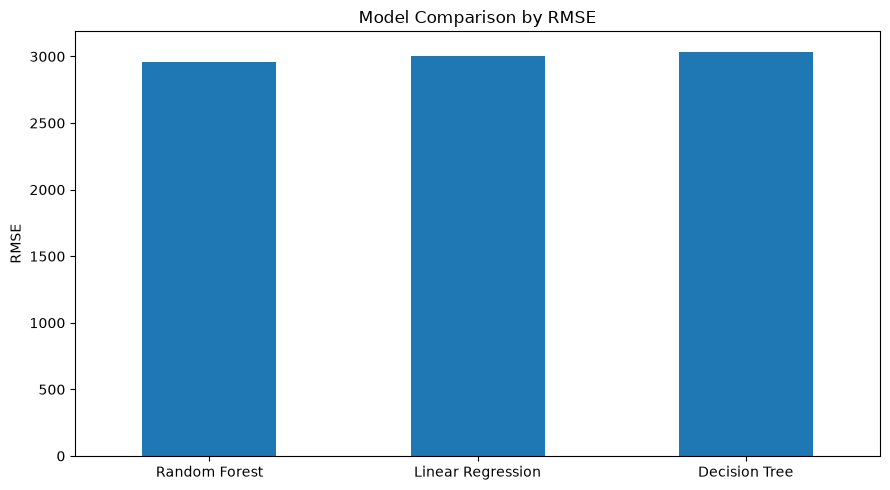

In [15]:
# Visual comparison of model performance
fig, ax = plt.subplots(figsize=(9,5))
results_df.plot(x="Model", y="RMSE", kind="bar", ax=ax, legend=False)
ax.set_title("Model Comparison by RMSE")
ax.set_ylabel("RMSE")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Random Forest Feature Importance

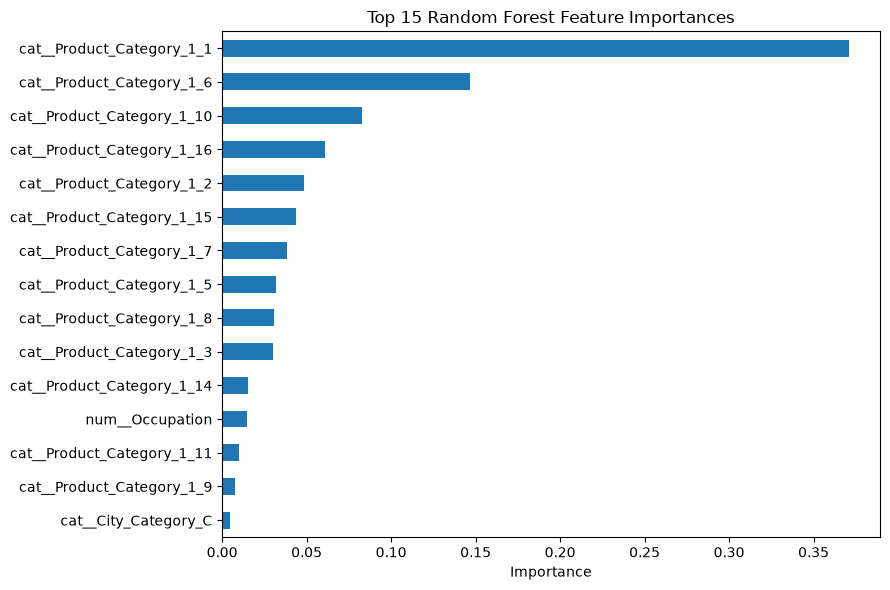

cat__Product_Category_1_1     0.370772
cat__Product_Category_1_6     0.146875
cat__Product_Category_1_10    0.082979
cat__Product_Category_1_16    0.060736
cat__Product_Category_1_2     0.048723
cat__Product_Category_1_15    0.043826
cat__Product_Category_1_7     0.038505
cat__Product_Category_1_5     0.032104
cat__Product_Category_1_8     0.030732
cat__Product_Category_1_3     0.029979
cat__Product_Category_1_14    0.015235
num__Occupation               0.014822
cat__Product_Category_1_11    0.010077
cat__Product_Category_1_9     0.007386
cat__City_Category_C          0.004630
dtype: float64

In [16]:
# Extract feature names after preprocessing
rf_pipeline = fitted_models["Random Forest"]
rf_model = rf_pipeline.named_steps["model"]
fitted_preprocessor = rf_pipeline.named_steps["preprocessor"]

feature_names = fitted_preprocessor.get_feature_names_out()
importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

top_features = importances.head(15).sort_values()

plt.figure(figsize=(9,6))
top_features.plot(kind="barh")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

top_features.sort_values(ascending=False)


## Key Findings

Use the model comparison and feature-importance outputs above to report only the findings actually supported by the final run.

The project demonstrates:
- large-scale retail data cleaning and preprocessing
- categorical encoding and numerical scaling
- regression model comparison
- Random Forest feature importance analysis
- evaluation using MAE, RMSE and R²
